# Lista 7: Klasteryzacja

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff
from sklearn import cluster, metrics
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import timeit

## Zadanie 1: Analiza zbioru danych

In [2]:
source = arff.loadarff('Dry_Bean_Dataset.arff')
df = pd.DataFrame(source[0])
df['Class'] = df['Class'].str.decode('utf-8')
print(df.shape)
df.head()

(13611, 17)


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395.0,610.291,208.178117,173.888747,1.197191,0.549812,28715.0,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734.0,638.018,200.524796,182.734419,1.097356,0.411785,29172.0,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380.0,624.110,212.826130,175.931143,1.209713,0.562727,29690.0,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008.0,645.884,210.557999,182.516516,1.153638,0.498616,30724.0,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140.0,620.134,201.847882,190.279279,1.060798,0.333680,30417.0,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [3]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


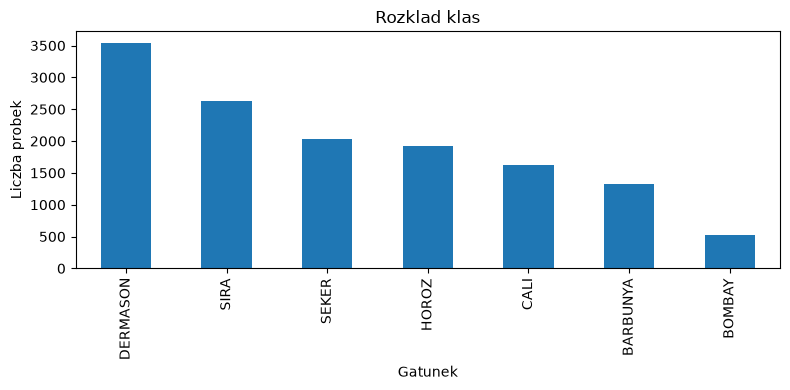

In [4]:
counts = df['Class'].value_counts()
print(counts)
fig, ax = plt.subplots(figsize=(8, 4))
counts.plot(kind='bar', ax=ax)
ax.set_title('Rozklad klas')
ax.set_xlabel('Gatunek')
ax.set_ylabel('Liczba probek')
plt.tight_layout()

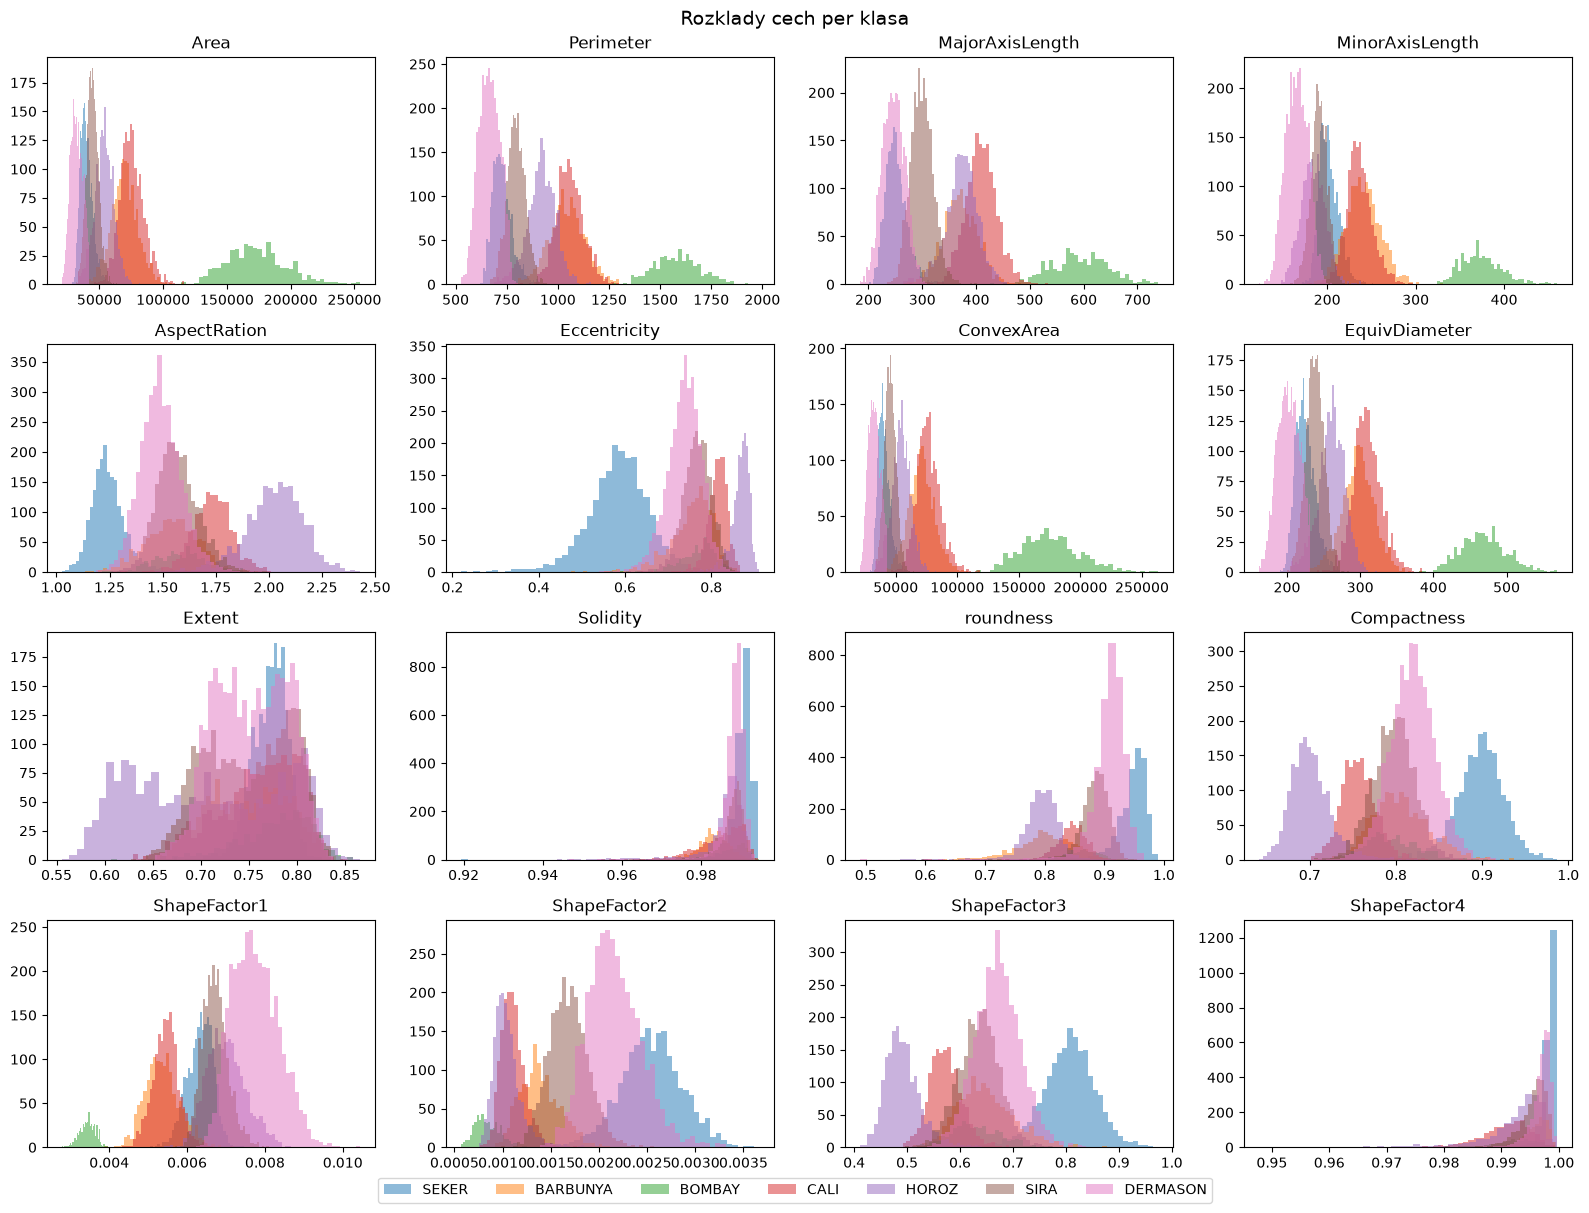

In [5]:
features = df.columns[:-1].tolist()
classes = df['Class'].unique()
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for i, feat in enumerate(features):
    ax = axes[i // 4][i % 4]
    for cls in classes:
        ax.hist(df.loc[df['Class'] == cls, feat], bins=40, alpha=0.5, label=cls)
    ax.set_title(feat)
handles, labels_leg = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels_leg, loc='lower center', ncol=7, bbox_to_anchor=(0.5, -0.02))
fig.suptitle('Rozklady cech per klasa', fontsize=14)
plt.tight_layout()

### Rozkłady cech
- Odmiana **BOMBAY** jest gigantyczna i łatwa do odróżnienia. **SEKER** jest bardzo okrągła, a **HOROZ** podłużna. Odmiany **DERMASON** i **SIRA** są niemal identyczne, przez co zlewają się w jedno

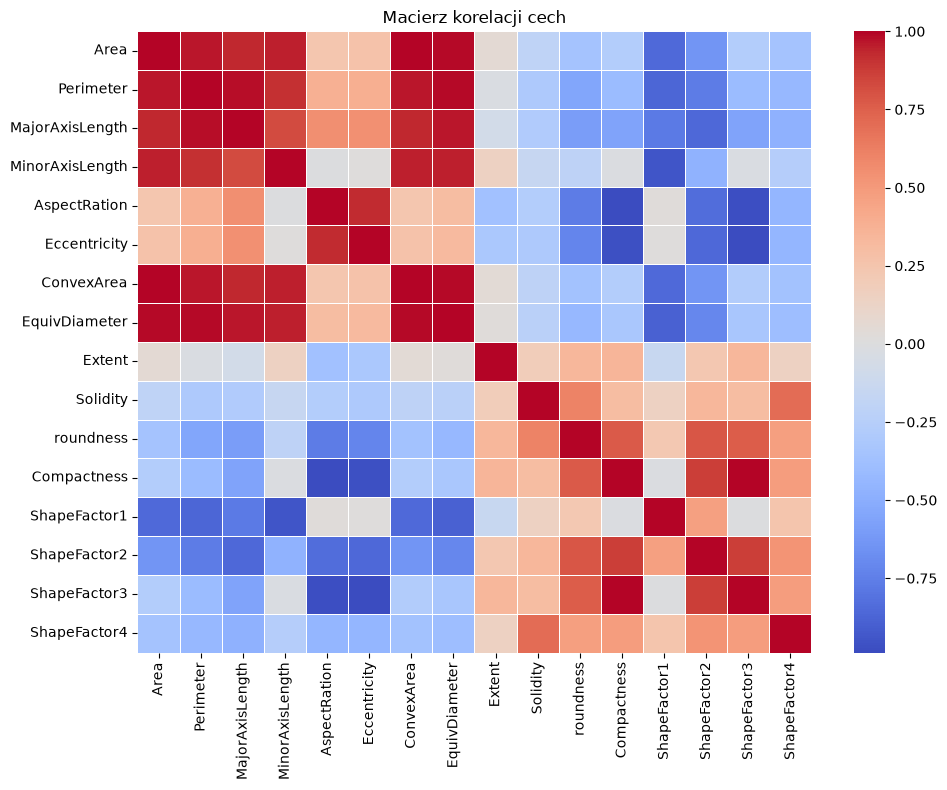

In [6]:
corr = df[features].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, ax=ax, cmap='coolwarm', linewidths=0.5, annot=False)
ax.set_title('Macierz korelacji cech')
plt.tight_layout()

Wszystkie cechy rozmiaru mówią dokładnie to samo

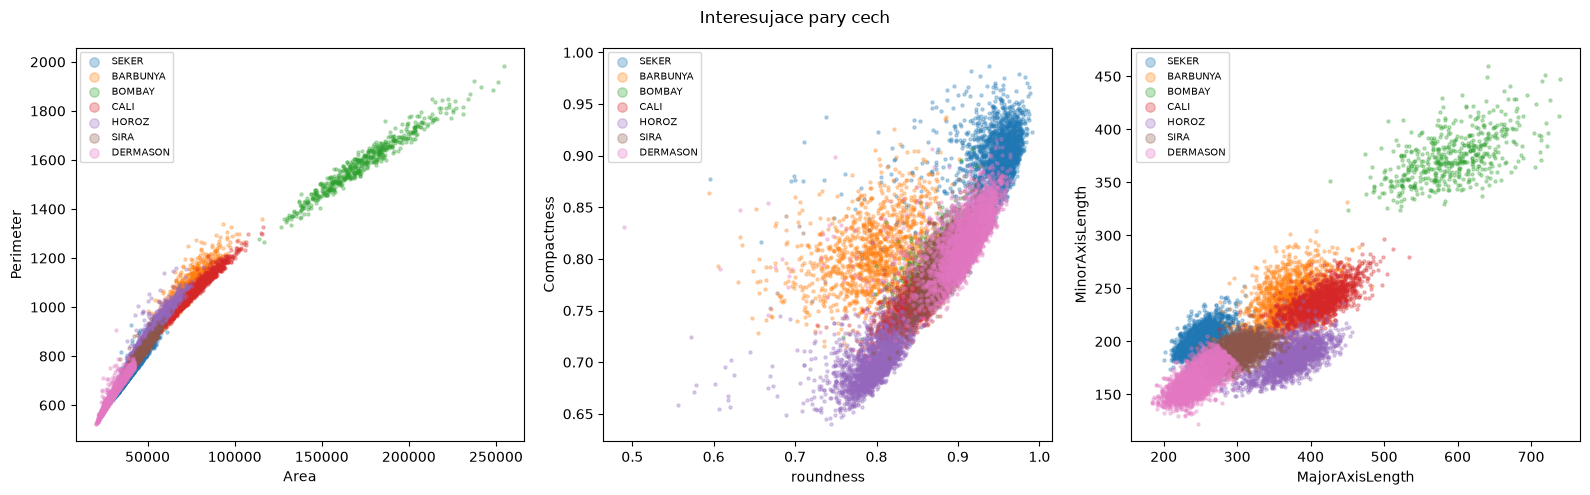

In [7]:
pairs = [('Area', 'Perimeter'), ('roundness', 'Compactness'), ('MajorAxisLength', 'MinorAxisLength')]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (fx, fy) in zip(axes, pairs):
    for cls in classes:
        mask = df['Class'] == cls
        ax.scatter(df.loc[mask, fx], df.loc[mask, fy], alpha=0.3, s=5, label=cls)
    ax.set_xlabel(fx)
    ax.set_ylabel(fy)
    ax.legend(markerscale=3, fontsize=7)
fig.suptitle('Interesujace pary cech')
plt.tight_layout()

In [8]:
labels_true = df['Class'].values
scaler = StandardScaler()
X = scaler.fit_transform(df[features])

pca = PCA(n_components=2) #redukcja wymiarow
X_pca = pca.fit_transform(X)
print(f'Wyjasniona wariancja (2 skladowe PCA): {pca.explained_variance_ratio_.sum():.2%}')

Wyjasniona wariancja (2 skladowe PCA): 81.90%


## Zad 2: Algorytm k-srednich

### 2.1 Przygotowanie

In [9]:
def purity_score(labels_true, labels_pred):
    cont_matrix = metrics.cluster.contingency_matrix(labels_true, labels_pred)
    return np.sum(np.max(cont_matrix, axis=0)) / np.sum(cont_matrix)

def plot_clustering(X_pca, labels, title=''):
    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='tab10', alpha=0.4, s=3)
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    ax.set_title(title)
    plt.colorbar(sc, ax=ax)
    plt.tight_layout()

Inercja (k=7): 48811.96


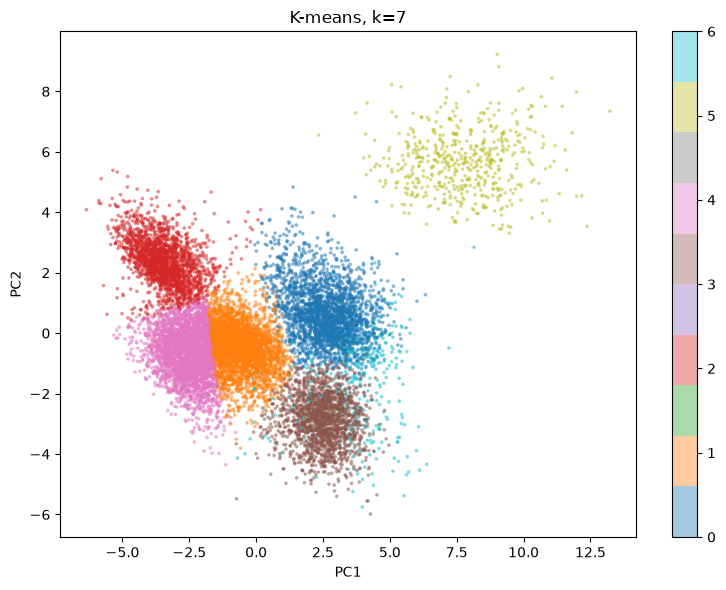

In [10]:
km_init = cluster.KMeans(n_clusters=7, random_state=42, n_init=10)
km_init.fit(X)
print(f'Inercja (k=7): {km_init.inertia_:.2f}')
plot_clustering(X_pca, km_init.labels_, 'K-means, k=7')

### 2.2 Badanie wplywu parametru k

In [11]:
k_range = range(2, 16)
k_list = list(k_range)
inertias, silhouettes, purities = [], [], []

for k in k_range:
    km = cluster.KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouettes.append(metrics.silhouette_score(X, labels, sample_size=2000, random_state=42))
    purities.append(purity_score(labels_true, labels))

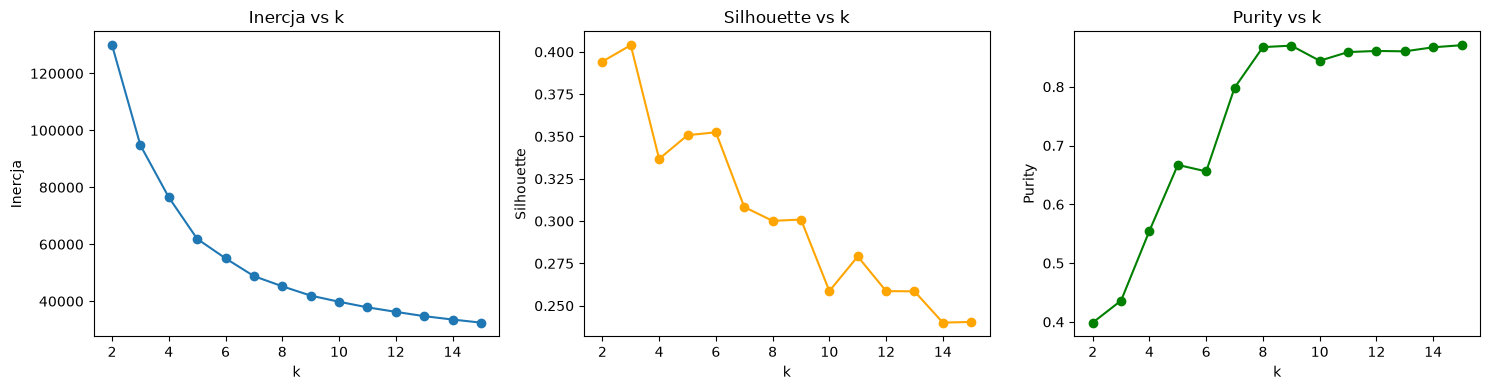

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(k_list, inertias, marker='o')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inercja')
axes[0].set_title('Inercja vs k')

axes[1].plot(k_list, silhouettes, marker='o', color='orange')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette')
axes[1].set_title('Silhouette vs k')

axes[2].plot(k_list, purities, marker='o', color='green')
axes[2].set_xlabel('k')
axes[2].set_ylabel('Purity')
axes[2].set_title('Purity vs k')

plt.tight_layout()

Geometrycznie dane najlepiej dzielą się na 3 duże grupy (najwyższe Silhouette), ale podział pod kątem rzeczywistych gatunków stabilizuje się przy 7-8 grupach (Purity). Wybór k=7 to najlepszy kompromis

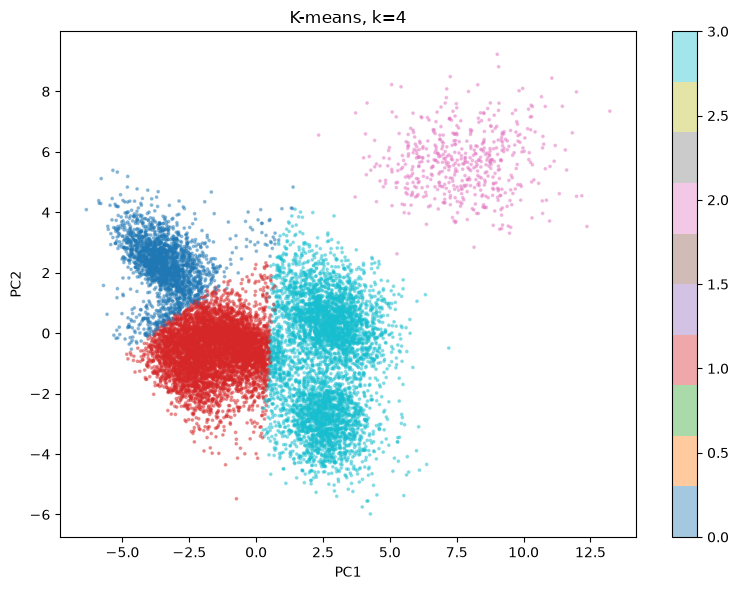

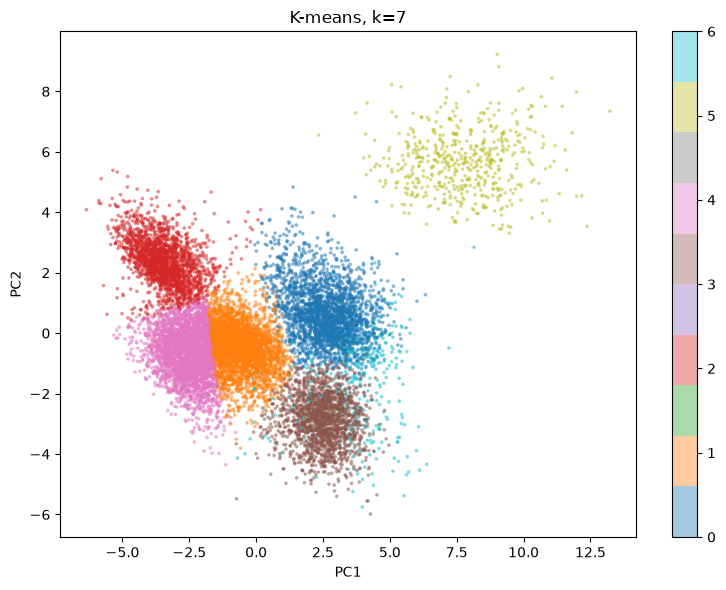

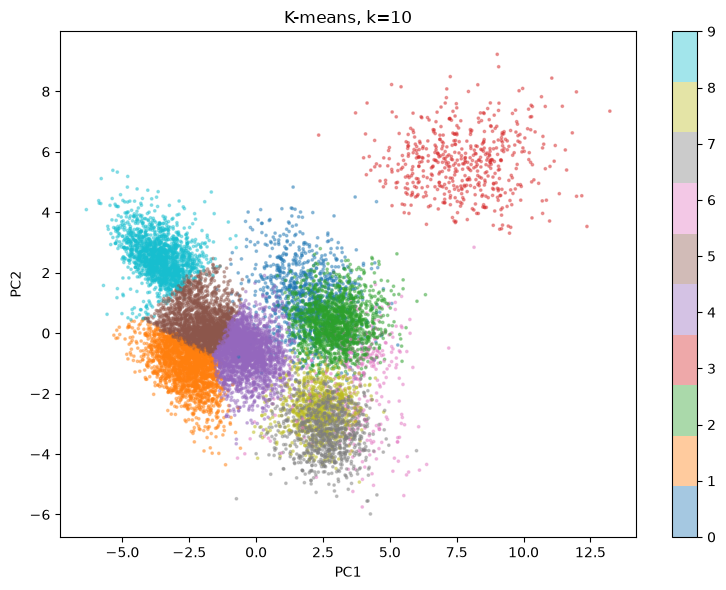

In [13]:
for k in [4, 7, 10]:
    km = cluster.KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    plot_clustering(X_pca, labels, f'K-means, k={k}')


- k=4: Za mało klastrów. Algorytm dobrze wydziela tylko skrajne odmiany (np. wielką BOMBAY), a całą resztę średnich i małych fasoli wrzuca do wspólnych, zbyt dużych worków
- k=7: Podział optymalny. Idealnie odcina odmianę BOMBAY i w miarę sensownie (choć ze sztucznymi, prostymi cięciami) dzieli trudną, zlepioną chmurę pozostałych gatunków fasoli
- k=10: Za dużo klastrów. Algorytm na siłę tnie naturalne, spójne grupy fasoli na mniejsze kawałki, które nie odpowiadają żadnym rzeczywistym gatunkom

## Zad 3: Klasteryzacja aglomeracyjna

### 3.1 Badanie

In [14]:
sil_agg, pur_agg = [], []

for k in k_range:
    agg = cluster.AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = agg.fit_predict(X)
    sil_agg.append(metrics.silhouette_score(X, labels, sample_size=2000, random_state=42))
    pur_agg.append(purity_score(labels_true, labels))

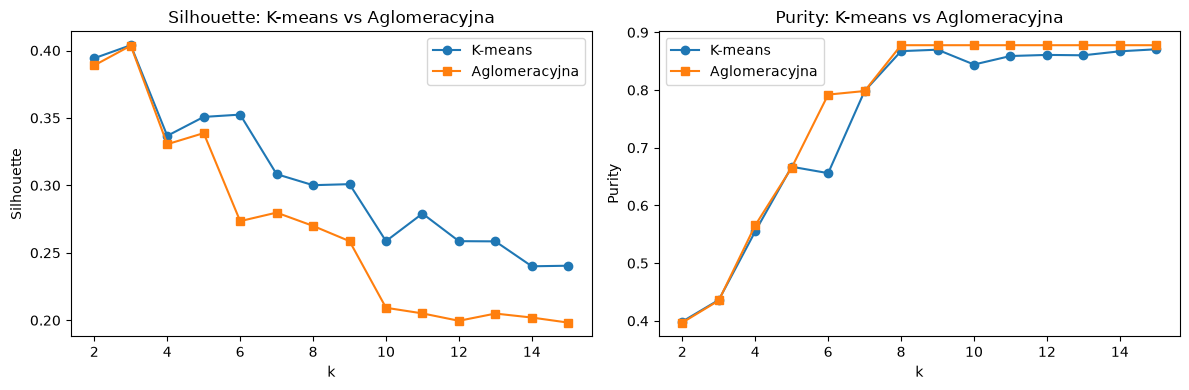

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_list, silhouettes, marker='o', label='K-means')
axes[0].plot(k_list, sil_agg, marker='s', label='Aglomeracyjna')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Silhouette')
axes[0].set_title('Silhouette: K-means vs Aglomeracyjna')
axes[0].legend()

axes[1].plot(k_list, purities, marker='o', label='K-means')
axes[1].plot(k_list, pur_agg, marker='s', label='Aglomeracyjna')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Purity')
axes[1].set_title('Purity: K-means vs Aglomeracyjna')
axes[1].legend()

plt.tight_layout()

spójność: K-means radzi sobie lepiej – tworzy wyraźniej odseparowane i bardziej spójne klastry

Zgodność z gatunkami: Oba algorytmy dają niemal identyczną czystość podziału

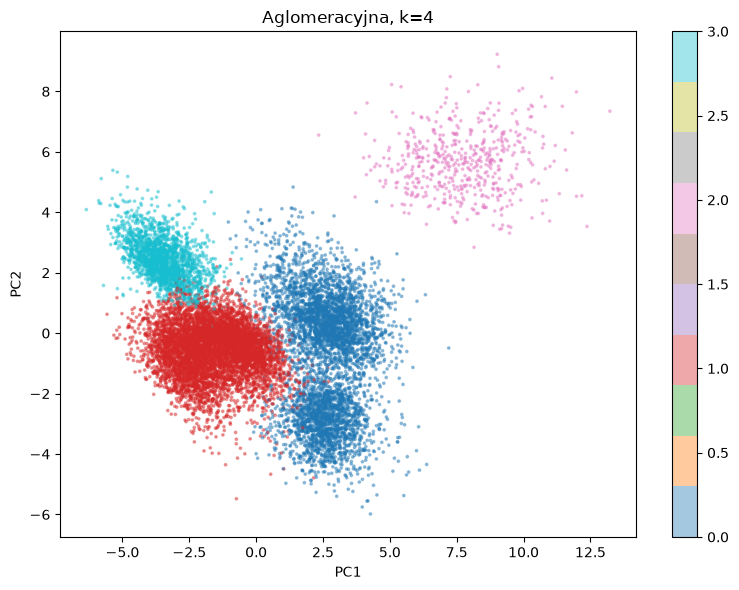

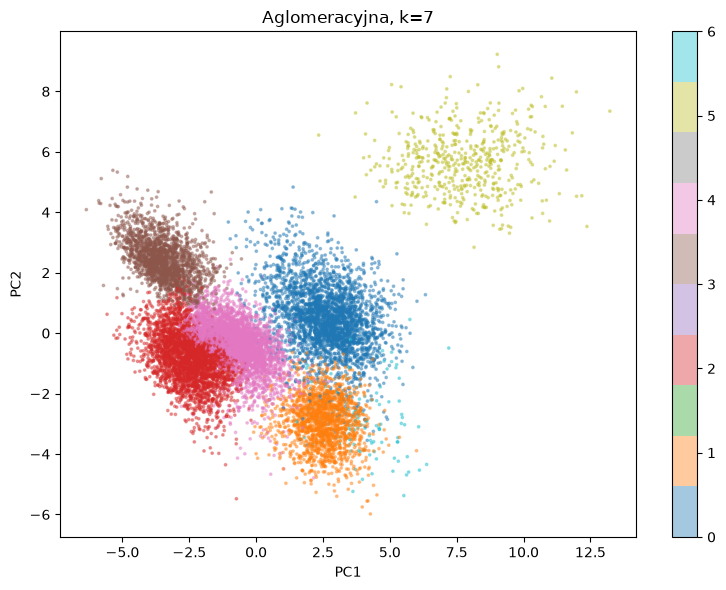

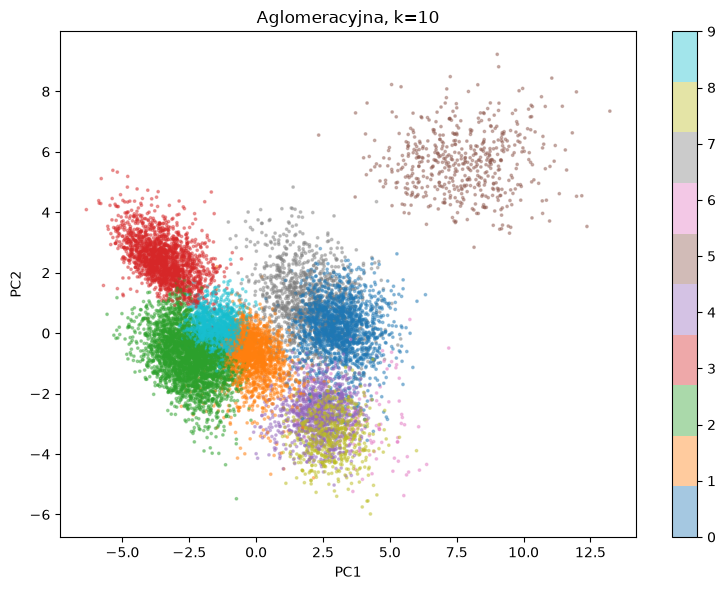

In [16]:
for k in [4, 7, 10]:
    agg = cluster.AgglomerativeClustering(n_clusters=k, linkage='ward')
    labels = agg.fit_predict(X)
    plot_clustering(X_pca, labels, f'Aglomeracyjna, k={k}')

### 3.2 Czas

In [ ]:
def run_kmeans():
    cluster.KMeans(n_clusters=7, random_state=42, n_init=10).fit(X)

def run_agg():
    cluster.AgglomerativeClustering(n_clusters=7, linkage='ward').fit(X)

n_reps = 5
t_km = timeit.timeit(run_kmeans, number=n_reps) / n_reps
t_agg = timeit.timeit(run_agg, number=n_reps) / n_reps

print(f'K-means:       {t_km:.3f} s (srednia z {n_reps} powtorzen)')
print(f'Aglomeracyjna: {t_agg:.3f} s (srednia z {n_reps} powtorzen)')
print(f'Stosunek czasu: {t_agg / t_km:.1f}x')

K-means:       1.501 s (srednia z 5 powtorzen)
Aglomeracyjna: 3.445 s (srednia z 5 powtorzen)
Stosunek czasu: 2.3x
